**Generate Realistice Data**

In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Reproducibility
np.random.seed(42)
#----------------
# User Table 
#----------------
n_users=1000
user_ids=np.arange(1,n_users+1)
users=pd.DataFrame({
    "user_id":user_ids,
    "Signup_date":pd.to_datetime("2023-01-01")+
    pd.to_timedelta(np.random.randint(0,365,n_users),unit="D"),
    "Country":np.random.choice(["India","US","UK","Africa"],n_users),
    "Device":np.random.choice(["Mobile","Laptop","tablet"],n_users)

})

#-----------------
#Events
#---------------

events_per_user=np.random.randint(5,20,size=n_users)
n_events_total = events_per_user.sum()#each user has multiple events
events=pd.DataFrame({
    "user_id":np.repeat(user_ids,events_per_user),
    "event_type":np.random.choice(["login","click","view","purchase"],n_events_total),
    "event_time":pd.to_datetime("2023-01-01")+
                 pd.to_timedelta(np.random.randint(0,365,n_events_total),unit="D")
    
        #Shuffle events(important for realistic dataset)
        
})
events=events.sample(frac=1,random_state=42).reset_index(drop=True)
        #---------------------
        #Subscription Table
        #---------------------
subs=pd.DataFrame({
    "user_id":user_ids,
    "plan":np.random.choice(["Basic","Pro"],n_users)
})
        #-------------------
        # Quick Validation
        #-------------------


In [67]:
events.head()

,user_id,event_type,event_time
0,271,purchase,2023-09-01
1,939,login,2023-07-23
2,315,click,2023-03-10
3,28,view,2023-04-17
4,577,purchase,2023-11-24


In [68]:
events.groupby(['user_id','event_type'])['user_id'].count()

user_id  event_type
1        click         1
         purchase      1
         view          5
2        click         2
         login         3
                      ..
999      purchase      7
1000     click         1
         login         2
         purchase      1
         view          2
Name: user_id, Length: 3757, dtype: int64

In [69]:
events.describe()

,user_id,event_time
count,11945.000000,11945
mean,501.554542,2023-07-01 05:29:28.204269568
min,1.000000,2023-01-01 00:00:00
25%,250.000000,2023-03-30 00:00:00
50%,503.000000,2023-07-01 00:00:00
75%,750.000000,2023-10-01 00:00:00
max,1000.000000,2023-12-31 00:00:00
std,288.413393,NaN


In [70]:
count_by_event_type=(
    events.groupby('event_type').size()
.reset_index(name='count').sort_values(by='count')
)
count_by_event_type

,event_type,count
2,purchase,2922
3,view,2990
0,click,2997
1,login,3036


In [71]:
subs['plan'].value_counts().reset_index(name='count')

,plan,count
0,Pro,513
1,Basic,487


In [72]:
users.head()

,user_id,Signup_date,Country,Device
0,1,2023-04-13,UK,Mobile
1,2,2023-12-15,UK,tablet
2,3,2023-09-28,India,Mobile
3,4,2023-04-17,US,tablet
4,5,2023-03-13,US,Mobile


**One row per user**:
**Aggregate Events**

In [73]:
events_agg=(
events.groupby("user_id").agg(
    total_events=("event_type","count"),
    unique_events=("event_type","nunique"),
    last_event_time=("event_time","max")
)
.reset_index()
)
events_agg


,user_id,total_events,unique_events,last_event_time
0,1,7,3,2023-10-13
1,2,11,4,2023-12-09
2,3,12,4,2023-12-30
3,4,16,4,2023-12-31
4,5,17,4,2023-10-30
...,...,...,...,...
995,996,7,4,2023-12-04
996,997,17,4,2023-11-11
997,998,14,4,2023-11-20
998,999,16,3,2023-12-28


In [74]:
data=(
    users
    .merge(events_agg,on="user_id",how="left")
    .merge(subs,on="user_id",how="left")
)
data

,user_id,Signup_date,Country,Device,total_events,unique_events,last_event_time,plan
0,1,2023-04-13,UK,Mobile,7,3,2023-10-13,Basic
1,2,2023-12-15,UK,tablet,11,4,2023-12-09,Basic
2,3,2023-09-28,India,Mobile,12,4,2023-12-30,Basic
3,4,2023-04-17,US,tablet,16,4,2023-12-31,Pro
4,5,2023-03-13,US,Mobile,17,4,2023-10-30,Basic
...,...,...,...,...,...,...,...,...
995,996,2023-02-07,Africa,tablet,7,4,2023-12-04,Pro
996,997,2023-10-20,Africa,tablet,17,4,2023-11-11,Basic
997,998,2023-05-19,UK,Laptop,14,4,2023-11-20,Pro
998,999,2023-12-22,UK,tablet,16,3,2023-12-28,Pro


**Checking the columns of users and events_agg**

In [75]:
print(users.columns)
print(events_agg.columns)

Index(['user_id', 'Signup_date', 'Country', 'Device'], dtype='object')
Index(['user_id', 'total_events', 'unique_events', 'last_event_time'], dtype='object')


In [76]:
data.head()

,user_id,Signup_date,Country,Device,total_events,unique_events,last_event_time,plan
0,1,2023-04-13,UK,Mobile,7,3,2023-10-13,Basic
1,2,2023-12-15,UK,tablet,11,4,2023-12-09,Basic
2,3,2023-09-28,India,Mobile,12,4,2023-12-30,Basic
3,4,2023-04-17,US,tablet,16,4,2023-12-31,Pro
4,5,2023-03-13,US,Mobile,17,4,2023-10-30,Basic


In [77]:
data.describe()

,user_id,Signup_date,total_events,unique_events,last_event_time
count,1000.000000,1000,1000.000000,1000.000000,1000
mean,500.500000,2023-07-01 13:22:04.800000,11.945000,3.757000,2023-11-28 18:46:04.800000256
min,1.000000,2023-01-01 00:00:00,5.000000,2.000000,2023-05-12 00:00:00
25%,250.750000,2023-04-08 00:00:00,8.000000,4.000000,2023-11-17 00:00:00
50%,500.500000,2023-07-01 12:00:00,12.000000,4.000000,2023-12-09 00:00:00
75%,750.250000,2023-09-27 06:00:00,16.000000,4.000000,2023-12-22 00:00:00
max,1000.000000,2023-12-31 00:00:00,19.000000,4.000000,2023-12-31 00:00:00
std,288.819436,NaN,4.272965,0.479772,NaN


**Checking for null values in the data**

In [78]:
data.isna().sum()

user_id            0
Signup_date        0
Country            0
Device             0
total_events       0
unique_events      0
last_event_time    0
plan               0
dtype: int64

**Checking if there any duplicated values**

In [79]:
data.duplicated().sum()

np.int64(0)

**Count each device type in each country**

In [80]:
country_wise_device=(
    data.groupby(["Country","Device"])
        .size()
        #.sort_values(ascending=False)
        .reset_index(name="count")
        
)
country_wise_device

,Country,Device,count
0,Africa,Laptop,81
1,Africa,Mobile,71
2,Africa,tablet,75
3,India,Laptop,98
4,India,Mobile,94
5,India,tablet,74
6,UK,Laptop,85
7,UK,Mobile,95
8,UK,tablet,76
9,US,Laptop,85


**Download the generated data for furthuer use in sql and excel**

In [81]:
data.to_csv("saas_data.csv",index=False)

**To check the total sign up count by country wise**

In [82]:
data.columns

Index(['user_id', 'Signup_date', 'Country', 'Device', 'total_events',
       'unique_events', 'last_event_time', 'plan'],
      dtype='object')

In [83]:
country_count=(
    data.groupby("Country")["Signup_date"]
    .count()
    .sort_values(ascending=False)
    .reset_index(name="count")
)
country_count

,Country,count
0,India,266
1,UK,256
2,US,251
3,Africa,227


In [84]:
data.columns

Index(['user_id', 'Signup_date', 'Country', 'Device', 'total_events',
       'unique_events', 'last_event_time', 'plan'],
      dtype='object')

**Visually showing the signup_count by country**

<Axes: xlabel='Country', ylabel='count'>

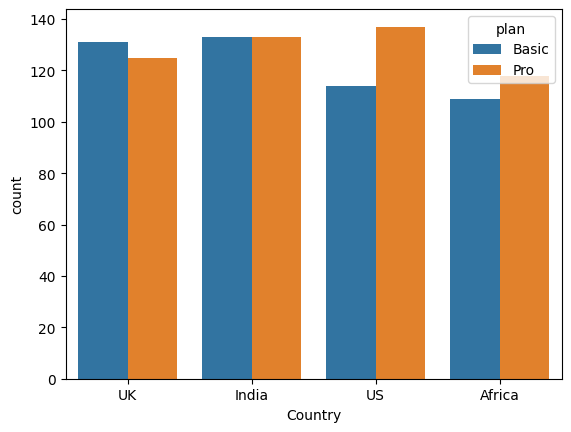

In [85]:
sns.countplot(x=data['Country'],hue=data['plan'])

**To show monthly signup trend analysis**

In [86]:
data['signup_month']=data['Signup_date'].dt.to_period('M')

In [87]:
data.columns

Index(['user_id', 'Signup_date', 'Country', 'Device', 'total_events',
       'unique_events', 'last_event_time', 'plan', 'signup_month'],
      dtype='object')

In [88]:
monthly_signup_trend=(
    data.groupby('signup_month')['Signup_date']
.count().reset_index(name='total_count')
.sort_index()
#.sort_values(by='total_count',ascending=False)
)
monthly_signup_trend

,signup_month,total_count
0,2023-01,78
1,2023-02,90
2,2023-03,60
3,2023-04,91
4,2023-05,96
5,2023-06,84
6,2023-07,75
7,2023-08,104
8,2023-09,82
9,2023-10,79


**Showing the key insight of User sign_up trend analysis**

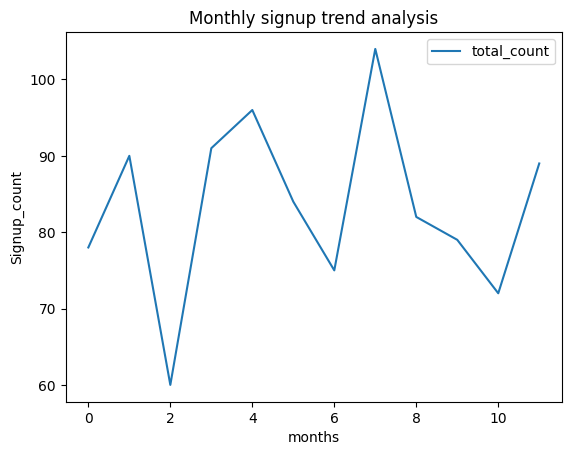

In [89]:
monthly_signup_trend.plot()
plt.xlabel("months")
plt.ylabel("Signup_count")
plt.title("Monthly signup trend analysis")
plt.show()

In [90]:
data

,user_id,Signup_date,Country,Device,total_events,unique_events,last_event_time,plan,signup_month
0,1,2023-04-13,UK,Mobile,7,3,2023-10-13,Basic,2023-04
1,2,2023-12-15,UK,tablet,11,4,2023-12-09,Basic,2023-12
2,3,2023-09-28,India,Mobile,12,4,2023-12-30,Basic,2023-09
3,4,2023-04-17,US,tablet,16,4,2023-12-31,Pro,2023-04
4,5,2023-03-13,US,Mobile,17,4,2023-10-30,Basic,2023-03
...,...,...,...,...,...,...,...,...,...
995,996,2023-02-07,Africa,tablet,7,4,2023-12-04,Pro,2023-02
996,997,2023-10-20,Africa,tablet,17,4,2023-11-11,Basic,2023-10
997,998,2023-05-19,UK,Laptop,14,4,2023-11-20,Pro,2023-05
998,999,2023-12-22,UK,tablet,16,3,2023-12-28,Pro,2023-12


**Creating new column called last_event_month**

In [91]:
data['last_event_month']=data['last_event_time'].dt.to_period('M')

In [92]:
data.columns

Index(['user_id', 'Signup_date', 'Country', 'Device', 'total_events',
       'unique_events', 'last_event_time', 'plan', 'signup_month',
       'last_event_month'],
      dtype='object')

In [93]:
left_users_trend=(
                    data.groupby('last_event_month')['last_event_time']
                    .count().reset_index(name='Leaving_users_count')
                    .sort_index()
)
left_users_trend

,last_event_month,Leaving_users_count
0,2023-05,2
1,2023-06,3
2,2023-07,3
3,2023-08,19
4,2023-09,38
5,2023-10,94
6,2023-11,209
7,2023-12,632


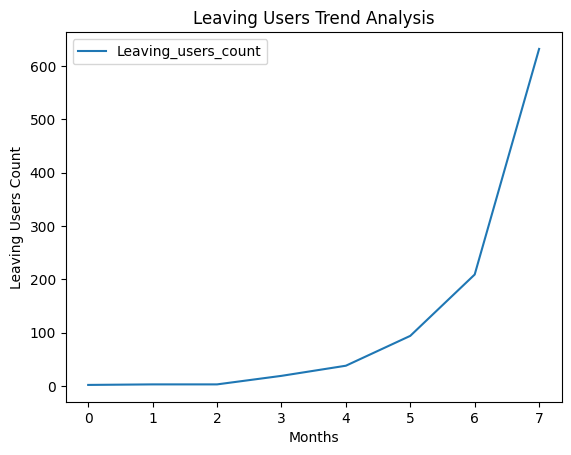

In [94]:
left_users_trend.plot()
plt.xlabel("Months")
plt.ylabel("Leaving Users Count")
plt.title("Leaving Users Trend Analysis")
plt.show()

**Adding New column 'acquisition_channel' in the user data frame**

In [95]:
#Add Acquisation source

users['acquisition_channel']=np.random.choice(
    ['Organic','Google Ads','Facebook Ads','Referral'],
    size=len(users),
    p=[0.4,0.3,0.2,0.1] # Realstic distributions

)

In [96]:
users.columns

Index(['user_id', 'Signup_date', 'Country', 'Device', 'acquisition_channel'], dtype='object')

**Add Revenue column to the events data frame**

In [97]:
events.columns

Index(['user_id', 'event_type', 'event_time'], dtype='object')

In [98]:
#Merge events and subs table
events=events.merge(subs[['user_id','plan']],on='user_id',how='left')
events=events.merge(users[['user_id','acquisition_channel']],on='user_id',how='left')

In [99]:
events

,user_id,event_type,event_time,plan,acquisition_channel
0,271,purchase,2023-09-01,Basic,Facebook Ads
1,939,login,2023-07-23,Basic,Organic
2,315,click,2023-03-10,Pro,Google Ads
3,28,view,2023-04-17,Basic,Organic
4,577,purchase,2023-11-24,Basic,Organic
...,...,...,...,...,...
11940,944,purchase,2023-06-03,Basic,Google Ads
11941,438,login,2023-10-03,Pro,Organic
11942,456,purchase,2023-02-25,Pro,Google Ads
11943,72,login,2023-12-09,Basic,Organic


In [100]:
# Add revenue column(default=0)
events['revenue']=0
# Assign revenue only for purchase events
purchase_mask=events['event_type']=='purchase'
events.loc[purchase_mask,'plan']=np.random.choice(['Basic','Pro'],#pricing tiers
                   size=purchase_mask.sum(),
                #p=[0.7,0.3]                                  
)

In [101]:
#Map Revenue
plan_price={'Basic':200,'Pro':500}
events['revenue']=events['plan'].map(plan_price).fillna(0)

In [102]:
events

,user_id,event_type,event_time,plan,acquisition_channel,revenue
0,271,purchase,2023-09-01,Pro,Facebook Ads,500
1,939,login,2023-07-23,Basic,Organic,200
2,315,click,2023-03-10,Pro,Google Ads,500
3,28,view,2023-04-17,Basic,Organic,200
4,577,purchase,2023-11-24,Basic,Organic,200
...,...,...,...,...,...,...
11940,944,purchase,2023-06-03,Pro,Google Ads,500
11941,438,login,2023-10-03,Pro,Organic,500
11942,456,purchase,2023-02-25,Basic,Google Ads,200
11943,72,login,2023-12-09,Basic,Organic,200


In [103]:
acquisition_calc=(
    events.groupby(['acquisition_channel','plan']).agg(
        total_signups=("revenue","count"),
        total_revenue=("revenue","sum")

    ).reset_index().sort_values(by='total_revenue',ascending=False)
)
acquisition_calc

,acquisition_channel,plan,total_signups,total_revenue
5,Organic,Pro,2479,1239500
3,Google Ads,Pro,1818,909000
1,Facebook Ads,Pro,1146,573000
4,Organic,Basic,2309,461800
2,Google Ads,Basic,1747,349400
7,Referral,Pro,608,304000
0,Facebook Ads,Basic,1234,246800
6,Referral,Basic,604,120800


**We simulate sessions based on time gaps for that first we sort the events**

In [104]:
events=events.sort_values(by=(['user_id','event_time']))
events

,user_id,event_type,event_time,plan,acquisition_channel,revenue
8916,1,click,2023-04-08,Basic,Google Ads,200
1640,1,view,2023-04-09,Basic,Google Ads,200
10945,1,view,2023-06-07,Basic,Google Ads,200
10165,1,view,2023-07-04,Basic,Google Ads,200
7766,1,view,2023-07-26,Basic,Google Ads,200
...,...,...,...,...,...,...
2216,1000,view,2023-03-05,Basic,Google Ads,200
11164,1000,click,2023-03-06,Basic,Google Ads,200
817,1000,login,2023-04-10,Basic,Google Ads,200
2628,1000,purchase,2023-04-15,Basic,Google Ads,200


**Create Sessions Ids**

In [105]:
# Calculate time difference between events per count
events["time_diff"]=events.groupby("user_id")["event_time"].diff()
#events['time_diff']
#New sessions if gap>30 minutes
events["new_sessions"]=(events["time_diff"]>pd.Timedelta(minutes=30))|(events["time_diff"].isna())
#events[events["new_sessions"]]
# gn sessions IDs
events["session_id"]=events.groupby("user_id")["new_sessions"].cumsum()

In [106]:
# clean up
events.drop(columns=["time_diff","new_sessions"],inplace=True)

**Add Time-Based Churn (Realistic)**

In [107]:
last_activity=events.groupby("user_id")["event_time"].max().reset_index()

last_activity.rename(columns={"event_time":"last_activity_date"},inplace=True)
last_activity

,user_id,last_activity_date
0,1,2023-10-13
1,2,2023-12-09
2,3,2023-12-30
3,4,2023-12-31
4,5,2023-10-30
...,...,...
995,996,2023-12-04
996,997,2023-11-11
997,998,2023-11-20
998,999,2023-12-28


**Merge into subscriptions**

In [108]:
subs=subs.merge(last_activity,on="user_id")
subs

,user_id,plan,last_activity_date
0,1,Basic,2023-10-13
1,2,Basic,2023-12-09
2,3,Basic,2023-12-30
3,4,Pro,2023-12-31
4,5,Basic,2023-10-30
...,...,...,...
995,996,Pro,2023-12-04
996,997,Basic,2023-11-11
997,998,Pro,2023-11-20
998,999,Pro,2023-12-28


**User what they do +last activity**

In [109]:
user_activity=events.groupby("user_id").agg(
    {
        "event_type":lambda x:list(x),
        # all actions
        "event_time":"max"             #Last_activity
    }
).reset_index()
user_activity.rename(columns={"event_time":"last_activity_date"},inplace=True)


**Identify  inactive users**

In [110]:
reference_date=pd.to_datetime("2023-12-31")
user_activity["days_inactive"]=(
    reference_date-user_activity["last_activity_date"]
).dt.days
user_activity

,user_id,event_type,last_activity_date,days_inactive
0,1,"[click, view, view, view, view, view, purchase]",2023-10-13,79
1,2,"[purchase, view, purchase, purchase, click, lo...",2023-12-09,22
2,3,"[view, click, login, login, purchase, purchase...",2023-12-30,1
3,4,"[login, purchase, click, view, view, view, cli...",2023-12-31,0
4,5,"[view, login, click, login, login, login, clic...",2023-10-30,62
...,...,...,...,...
995,996,"[login, login, click, purchase, login, view, v...",2023-12-04,27
996,997,"[purchase, login, purchase, view, view, click,...",2023-11-11,50
997,998,"[login, login, view, click, purchase, view, lo...",2023-11-20,41
998,999,"[purchase, login, login, purchase, login, clic...",2023-12-28,3


**Define churn logic**

In [111]:
# if user inactive for 30+ days-churned 
reference_date=pd.to_datetime("2023-12-31")

subs["days_inactive"]=(reference_date-subs["last_activity_date"]).dt.days

#subs["days_inactive"]
subs["churned"]=(subs["days_inactive"]>30)#.astype(int)
subs["churned"]

0       True
1      False
2      False
3      False
4       True
       ...  
995    False
996     True
997     True
998    False
999     True
Name: churned, Length: 1000, dtype: bool

**Add Subscription Dates**

In [112]:
subs["start_date"]=users["Signup_date"]

subs["end_date"]=np.where(
    subs["churned"]==1,
    subs["last_activity_date"],
    pd.NaT
    )
subs["end_date"]=pd.to_datetime(subs["end_date"])
subs

,user_id,plan,last_activity_date,days_inactive,churned,start_date,end_date
0,1,Basic,2023-10-13,79,True,2023-04-13,2023-10-13
1,2,Basic,2023-12-09,22,False,2023-12-15,NaT
2,3,Basic,2023-12-30,1,False,2023-09-28,NaT
3,4,Pro,2023-12-31,0,False,2023-04-17,NaT
4,5,Basic,2023-10-30,62,True,2023-03-13,2023-10-30
...,...,...,...,...,...,...,...
995,996,Pro,2023-12-04,27,False,2023-02-07,NaT
996,997,Basic,2023-11-11,50,True,2023-10-20,2023-11-11
997,998,Pro,2023-11-20,41,True,2023-05-19,2023-11-20
998,999,Pro,2023-12-28,3,False,2023-12-22,NaT


In [113]:
events.columns

Index(['user_id', 'event_type', 'event_time', 'plan', 'acquisition_channel',
       'revenue', 'session_id'],
      dtype='object')

**lets check users dataframe info and columns**

In [114]:
users

,user_id,Signup_date,Country,Device,acquisition_channel
0,1,2023-04-13,UK,Mobile,Google Ads
1,2,2023-12-15,UK,tablet,Google Ads
2,3,2023-09-28,India,Mobile,Referral
3,4,2023-04-17,US,tablet,Organic
4,5,2023-03-13,US,Mobile,Google Ads
...,...,...,...,...,...
995,996,2023-02-07,Africa,tablet,Organic
996,997,2023-10-20,Africa,tablet,Referral
997,998,2023-05-19,UK,Laptop,Organic
998,999,2023-12-22,UK,tablet,Organic


**count of signups by acquisition_channel**

In [115]:
events=events.drop(columns=['acquisition_channel','Country'],errors='ignore')

In [116]:
events=events.merge(users[['user_id','acquisition_channel','Country']],on='user_id',how='left')
events

,user_id,event_type,event_time,plan,revenue,session_id,acquisition_channel,Country
0,1,click,2023-04-08,Basic,200,1,Google Ads,UK
1,1,view,2023-04-09,Basic,200,2,Google Ads,UK
2,1,view,2023-06-07,Basic,200,3,Google Ads,UK
3,1,view,2023-07-04,Basic,200,4,Google Ads,UK
4,1,view,2023-07-26,Basic,200,5,Google Ads,UK
...,...,...,...,...,...,...,...,...
11940,1000,view,2023-03-05,Basic,200,2,Google Ads,Africa
11941,1000,click,2023-03-06,Basic,200,3,Google Ads,Africa
11942,1000,login,2023-04-10,Basic,200,4,Google Ads,Africa
11943,1000,purchase,2023-04-15,Basic,200,5,Google Ads,Africa


In [117]:
country_perc=events.groupby(['Country'])['revenue'].sum()*100/(events['revenue'].sum())
country_perc=country_perc.sort_values(ascending=False)
country_perc

Country
India     26.185096
UK        25.904431
US        25.806912
Africa    22.103561
Name: revenue, dtype: float64

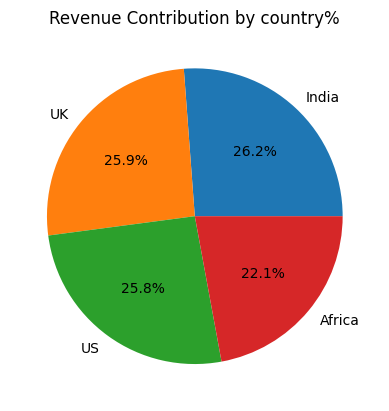

In [118]:
plt.figure()
plt.pie(
    country_perc,
    labels=country_perc.index,
    autopct="%1.1f%%"
)
plt.title("Revenue Contribution by country%")
plt.show()

**Percentile Contribution of revenue generated by acquisition_channel**

In [119]:
events

,user_id,event_type,event_time,plan,revenue,session_id,acquisition_channel,Country
0,1,click,2023-04-08,Basic,200,1,Google Ads,UK
1,1,view,2023-04-09,Basic,200,2,Google Ads,UK
2,1,view,2023-06-07,Basic,200,3,Google Ads,UK
3,1,view,2023-07-04,Basic,200,4,Google Ads,UK
4,1,view,2023-07-26,Basic,200,5,Google Ads,UK
...,...,...,...,...,...,...,...,...
11940,1000,view,2023-03-05,Basic,200,2,Google Ads,Africa
11941,1000,click,2023-03-06,Basic,200,3,Google Ads,Africa
11942,1000,login,2023-04-10,Basic,200,4,Google Ads,Africa
11943,1000,purchase,2023-04-15,Basic,200,5,Google Ads,Africa


In [120]:
percentile_count=(
    events.groupby('acquisition_channel')['revenue'].sum()*100/events['revenue']
          .sum()).reset_index(name='Percen%')
percentile_count

,acquisition_channel,Percen%
0,Facebook Ads,19.499084
1,Google Ads,29.931261
2,Organic,40.465714
3,Referral,10.103941


**Percentile count of signups by acquisition_channel**

C:\Users\mahes\AppData\Local\Temp\ipykernel_12772\1696166323.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=users['acquisition_channel'],data=users,palette='hls')


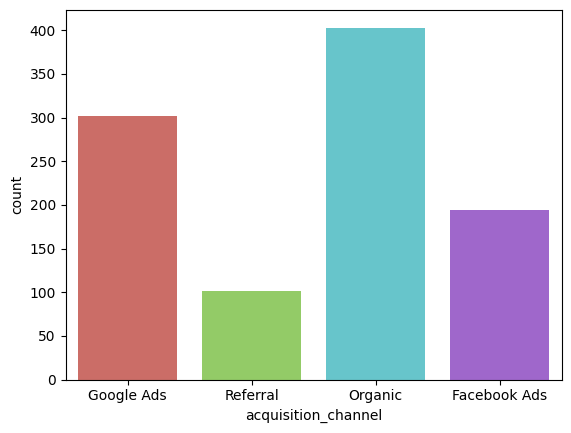

In [121]:
sns.countplot(x=users['acquisition_channel'],data=users,palette='hls')
#plt.xticks(rotation=45)
plt.show()

**Cohort Retention(Critical for SaaS)**

In [122]:
events=events.merge(users[['user_id','Signup_date']],on='user_id',how='left')

In [123]:
users.columns

Index(['user_id', 'Signup_date', 'Country', 'Device', 'acquisition_channel'], dtype='object')

**create cohort_months and activity_date columns**

In [124]:
events['cohort_month']=events['Signup_date'].dt.to_period('M')
events['activity_date']=events['event_time'].dt.to_period('M')


**create cohort_index column**

In [125]:
events['cohort_index']=(events['activity_date']-events['cohort_month']).apply(lambda x:x.n)
events['cohort_index']

0        0
1        0
2        2
3        3
4        3
        ..
11940   -8
11941   -8
11942   -7
11943   -7
11944   -2
Name: cohort_index, Length: 11945, dtype: int64

In [126]:
cohort_data=events.groupby(['cohort_month','cohort_index'])['user_id'].nunique().reset_index(name='count')

In [136]:
events[['activity_date','cohort_month']]

,activity_date,cohort_month
0,2023-04,2023-04
1,2023-04,2023-04
2,2023-06,2023-04
3,2023-07,2023-04
4,2023-07,2023-04
...,...,...
11940,2023-03,2023-11
11941,2023-03,2023-11
11942,2023-04,2023-11
11943,2023-04,2023-11


In [127]:
cohort_data

,cohort_month,cohort_index,count
0,2023-01,0,48
1,2023-01,1,41
2,2023-01,2,48
3,2023-01,3,50
4,2023-01,4,41
...,...,...,...
139,2023-12,-4,58
140,2023-12,-3,56
141,2023-12,-2,60
142,2023-12,-1,64


In [128]:
# Step 1:cohort table(2D)
cohort_table=events.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='user_id',
    aggfunc='nunique'
    )
cohort_table

cohort_index,-11,-10,-9,-8,-7,-6,-5,-4,-3,-2,...,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,,,,,,,,,,
2023-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,50.0,41.0,46.0,53.0,49.0,48.0,46.0,50.0,48.0
2023-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,51.0,62.0,63.0,59.0,57.0,57.0,61.0,58.0,59.0,NaN
2023-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.0,...,37.0,37.0,36.0,41.0,34.0,38.0,44.0,43.0,NaN,NaN
2023-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.0,55.0,...,56.0,52.0,56.0,56.0,54.0,51.0,57.0,NaN,NaN,NaN
2023-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.0,59.0,66.0,...,61.0,66.0,61.0,66.0,64.0,62.0,NaN,NaN,NaN,NaN
2023-06,NaN,NaN,NaN,NaN,NaN,NaN,52.0,47.0,60.0,52.0,...,50.0,51.0,49.0,47.0,52.0,NaN,NaN,NaN,NaN,NaN
2023-07,NaN,NaN,NaN,NaN,NaN,46.0,41.0,51.0,46.0,50.0,...,53.0,44.0,46.0,47.0,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,NaN,NaN,NaN,NaN,71.0,58.0,63.0,66.0,61.0,65.0,...,60.0,67.0,59.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,NaN,NaN,NaN,50.0,48.0,55.0,49.0,46.0,44.0,49.0,...,47.0,58.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [129]:
cohort_sizes=cohort_table.iloc[:,0]

In [130]:
# Calculate Retention 
retention=cohort_table.divide(cohort_sizes,axis=0)
retention

cohort_index,-11,-10,-9,-8,-7,-6,-5,-4,-3,-2,...,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,,,,,,,,,,
2023-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
